# Introduction to Machine Learning

In [1]:
using Plots

In [2]:
using DataFrames

In [3]:
using MLDatasets

In [4]:
using Clustering

In [5]:
using MultivariateStats

## 1. The Iris Dataset

In [6]:
using MLDatasets: Iris

In [7]:
?Iris

search: Iris grid cis



```julia
Iris(; as_df = true, dir = nothing)
```

Fisher's classic iris dataset. 

Measurements from 3 different species of iris: setosa, versicolor and virginica. There are 50 examples of each species.

There are 4 measurements for each example: sepal length, sepal width, petal length and petal width.  The measurements are in centimeters.

The module retrieves the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/iris).

NOTE: no pre-defined train-test split for this dataset. 

# Arguments

  * If `as_df = true`, load the data as dataframes instead of plain arrays.
  * You can pass a specific `dir` where to load or download the dataset, otherwise uses the default one.

# Fields

  * `metadata`: A dictionary containing additional information on the dataset.
  * `features`: The data features. An array if `as_df=false`, otherwise a dataframe.
  * `targets`: The targets for supervised learning. An array if `as_df=false`, otherwise a dataframe.
  * `dataframe`: A dataframe containing both `features` and `targets`. It is `nothing` if `as_df=false`, otherwise a dataframed.

# Methods

  * `dataset[i]`: Return observation(s) `i` as a named tuple of features and targets.
  * `dataset[:]`: Return all observations as a named tuple of features and targets.
  * `length(dataset)`: Number of observations.

# Examples

```julia-repl
julia> dataset = Iris()
Iris:
  metadata => Dict{String, Any} with 4 entries
  features => 150×4 DataFrame
  targets => 150×1 DataFrame
  dataframe => 150×5 DataFrame


julia> dataset[1:2]
(2×4 DataFrame
 Row │ sepallength  sepalwidth  petallength  petalwidth 
     │ Float64      Float64     Float64      Float64    
─────┼──────────────────────────────────────────────────
   1 │         5.1         3.5          1.4         0.2
   2 │         4.9         3.0          1.4         0.2, 2×1 DataFrame
 Row │ class       
     │ String15    
─────┼─────────────
   1 │ Iris-setosa
   2 │ Iris-setosa)

julia> X, y = Iris(as_df=false)[:]
([5.1 4.9 … 6.2 5.9; 3.5 3.0 … 3.4 3.0; 1.4 1.4 … 5.4 5.1; 0.2 0.2 … 2.3 1.8], InlineStrings.String15["Iris-setosa" "Iris-setosa" … "Iris-virginica" "Iris-virginica"])
```


In [8]:
F = Iris().features

Row,sepallength,sepalwidth,petallength,petalwidth
,Float64,Float64,Float64,Float64
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2
6,5.4,3.9,1.7,0.4
7,4.6,3.4,1.4,0.3
8,5.0,3.4,1.5,0.2
9,4.4,2.9,1.4,0.2


In [9]:
L = Iris().targets

Row,class
,String15
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
5,Iris-setosa
6,Iris-setosa
7,Iris-setosa
8,Iris-setosa
9,Iris-setosa


For computational purposes, we reload the data, but now not as a dataframe.

In [10]:
F, L = Iris(as_df=false)[:]

(features = [5.1 4.9 … 6.2 5.9; 3.5 3.0 … 3.4 3.0; 1.4 1.4 … 5.4 5.1; 0.2 0.2 … 2.3 1.8], targets = InlineStrings.String15["Iris-setosa" "Iris-setosa" … "Iris-virginica" "Iris-virginica"])

The labels are sorted according to each plant class.

In [11]:
L[1:5]

5-element Vector{InlineStrings.String15}:
 "Iris-setosa"
 "Iris-setosa"
 "Iris-setosa"
 "Iris-setosa"
 "Iris-setosa"

## 2. Clustering

In [12]:
using Clustering

In [13]:
C = kmeans(F, 3)

KmeansResult{Matrix{Float64}, Float64, Int64}([5.005999999999999 5.88360655737705 6.853846153846153; 3.4180000000000006 2.740983606557377 3.0769230769230766; 1.464 4.388524590163935 5.715384615384615; 0.2439999999999999 1.4344262295081966 2.053846153846153], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  3, 3, 2, 3, 3, 3, 2, 3, 3, 2], [0.02159199999999828, 0.19199199999999905, 0.1699920000000077, 0.2691920000000039, 0.039191999999999894, 0.46759199999999623, 0.1723920000000163, 0.003592000000011808, 0.6415920000000028, 0.1343920000000054  …  0.1573372781064677, 0.4419526627218886, 0.7316259070142621, 0.11272189349114115, 0.2727218934911093, 0.3557988165680399, 0.8221177102929289, 0.3996449704141867, 0.6919526627218886, 0.7071996775060541], [50, 61, 39], [50, 61, 39], 78.94506582597647, 7, true)

In [14]:
dump(C)

KmeansResult{Matrix{Float64}, Float64, Int64}
  centers: Array{Float64}((4, 3)) [5.005999999999999 5.88360655737705 6.853846153846153; 3.4180000000000006 2.740983606557377 3.0769230769230766; 1.464 4.388524590163935 5.715384615384615; 0.2439999999999999 1.4344262295081966 2.053846153846153]
  assignments: Array{Int64}((150,)) [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  3, 3, 2, 3, 3, 3, 2, 3, 3, 2]
  costs: Array{Float64}((150,)) [0.02159199999999828, 0.19199199999999905, 0.1699920000000077, 0.2691920000000039, 0.039191999999999894, 0.46759199999999623, 0.1723920000000163, 0.003592000000011808, 0.6415920000000028, 0.1343920000000054  …  0.1573372781064677, 0.4419526627218886, 0.7316259070142621, 0.11272189349114115, 0.2727218934911093, 0.3557988165680399, 0.8221177102929289, 0.3996449704141867, 0.6919526627218886, 0.7071996775060541]
  counts: Array{Int64}((3,)) [50, 61, 39]
  wcounts: Array{Int64}((3,)) [50, 61, 39]
  totalcost: Float64 78.94506582597647
  iterations: Int64 7
  converged: Bool 

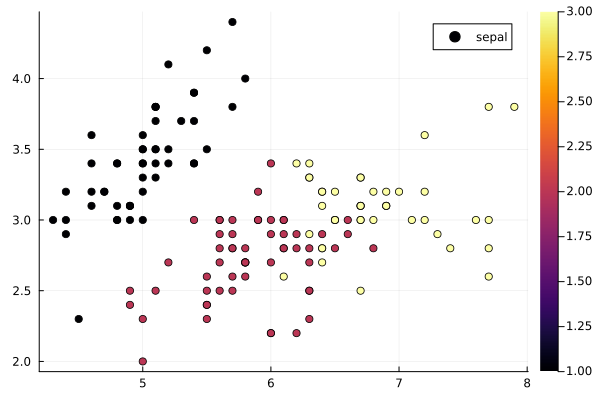

In [15]:
scatter(F[1,:], F[2,:], marker_z=C.assignments, label="sepal")

In [16]:
# savefig("figsepalclass.png")

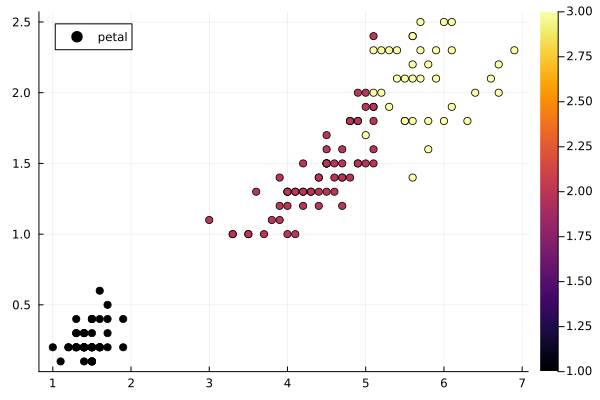

In [17]:
scatter(F[3,:], F[4, :], marker_z=C.assignments, label="petal", legend=:topleft)

In [18]:
# savefig("figpetalclass.png")

## 3. Principal Component Analysis

In [19]:
M3d = fit(PCA, F; maxoutdim=3)

PCA(indim = 4, outdim = 3, principalratio = 0.99481691454981)

Pattern matrix (unstandardized loadings):
────────────────────────────────────
         PC1         PC2         PC3
────────────────────────────────────
1   0.743227   0.323137   -0.162808
2  -0.169099   0.359152    0.167129
3   1.76063   -0.0865096   0.0203228
4   0.737583  -0.0367692   0.153858
────────────────────────────────────

Importance of components:
─────────────────────────────────────────────────────────
                                PC1        PC2        PC3
─────────────────────────────────────────────────────────
SS Loadings (Eigenvalues)  4.22484   0.242244   0.0785239
Variance explained         0.924616  0.0530156  0.0171851
Cumulative variance        0.924616  0.977632   0.994817
Proportion explained       0.929434  0.0532918  0.0172747
Cumulative proportion      0.929434  0.982725   1.0
─────────────────────────────────────────────────────────

In [20]:
dump(M3d)

PCA{Float64}
  mean: Array{Float64}((4,)) [5.843333333333335, 3.0540000000000007, 3.7586666666666693, 1.1986666666666672]
  proj: Array{Float64}((4, 3)) [-0.36158967738144976 0.6565398832858315 0.5809972798276175; 0.0822688898922141 0.7297123713264965 -0.5964180879381035; -0.8565721052905279 -0.17576740342865416 -0.07252407548696352; -0.3588439262482157 -0.07470647013503391 -0.5490609107266032]
  prinvars: Array{Float64}((3,)) [4.22484076832011, 0.2422435716275153, 0.07852390809415445]
  tprinvar: Float64 4.54560824804178
  tvar: Float64 4.569291275167782


In [21]:
F3d = MultivariateStats.transform(M3d, F)

3×150 Matrix{Float64}:
 2.68421     2.71539    2.88982    …  -1.76405    -1.90163   -1.38967
 0.326607   -0.169557  -0.137346       0.0785192   0.115877  -0.282887
 0.0215118   0.203521  -0.0247092     -0.130784   -0.722874  -0.362318

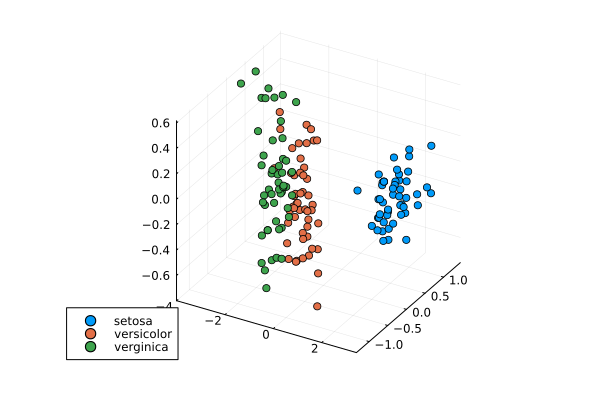

In [22]:
scatter(F3d[1,1:50], F3d[2,1:50], F3d[3,1:50], label="setosa")
scatter!(F3d[1,51:100], F3d[2,51:100], F3d[3,101:150], label="versicolor")
scatter!(F3d[1,101:150], F3d[2,101:150], F3d[3,101:150], label="verginica")

In [23]:
# savefig("figiris3dreduction.png")